# Viz-Prototypen (Sandbox)

Kein Teil von `Projekt_neu.ipynb` — hier baue ich die sieben Plots als wiederverwendbare Funktionen, damit sie später 1:1 in die Streamlit-App wandern können. Jede Funktion nimmt `capital`, `confidence`, `horizon_days` etc. als Argumente, kein hardcoded State mehr. Daten- und Vorzeichenkonvention bleibt mit dem Hauptnotebook kompatibel: positiv = Verlust bei VaR/ES, USD durchgängig.

Aufbau: erst Setup + Daten, dann eine große Funktions-Zelle mit allen sieben Plot-Funktionen, dann pro Plot eine kurze Demo-Zelle, die die Funktion mit Default-Werten aufruft und das PNG schreibt.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

# Setup analog Hauptnotebook — bewusst dieselben Werte
tickers = ['AAPL', 'TSLA', 'MSFT', 'META', 'AMZN', 'GOOGL', 'NVDA']
start_capital = 100_000
start_date = '2012-05-18'
end_date = '2026-04-01'
alpha = 0.05  # 95 %
days_1y = 252
mc_seed = 2
n_sims = 10_000

data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False, progress=False)['Adj Close']
returns_d = data.pct_change().dropna()
returns_log = np.log(data / data.shift(1)).dropna()
weights = np.array([1/len(tickers)] * len(tickers))
pf_d = returns_d.dot(weights)
pf_log = returns_log.dot(weights)

FIG_DIR = '/Users/leon/Desktop/Coding/QMA-Risk/docs/figures'


## Design-System

Die ersten Versionen sahen mir zu sehr nach Lehrbuch-matplotlib aus — Defaultblau, harter Rahmen, viele Linien. Ich will hier Richtung Fintech-Look (eher Stripe/Linear): eigene Palette mit Indigo + Coral, nur die nötigen Spines, mehr Luft, Klartext-Labels statt nackter Quantilzahlen. Alles unten zentral als `rcParams` und Farbkonstanten — die Plot-Funktionen ziehen sich daraus.

Helper `format_usd` formatiert dynamisch: bis 1 Mio mit Tausenderpunkt, ab 1 Mio kompakt als "Mio. $". Negative Werte mit typografischem Minus (U+2212). Damit skaliert die Achse sauber, egal ob der User 100 k oder 5 Mio. eingibt.

In [2]:
import matplotlib as mpl

# Farb-Palette
COLOR_PRIMARY     = "#1e3a8a"   # tiefes Indigo, Median / Hauptlinien
COLOR_ACCENT      = "#f43f5e"   # warmes Coral, Verlust / VaR / Tail
COLOR_BAND_INNER  = "#3b82f6"   # helles Indigo, 25-75-Band
COLOR_BAND_OUTER  = "#dbeafe"   # sehr helles Indigo, 5-95-Band
COLOR_NEUTRAL     = "#64748b"   # Slate, Achsen / Tick-Labels
COLOR_GRID        = "#e2e8f0"   # sehr helles Slate, Gridlines
COLOR_BG          = "#fafafa"   # off-white

# Methodenvergleich
COLOR_HIST  = "#1e3a8a"   # Indigo
COLOR_GAUSS = "#64748b"   # Slate, "Referenz"
COLOR_MC    = "#a855f7"   # Violett, Akzent

# Zentrale rcParams — gilt für alle Plots
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "figure.facecolor": COLOR_BG,
    "axes.facecolor": COLOR_BG,
    "axes.edgecolor": COLOR_NEUTRAL,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 14,
    "axes.labelsize": 10,
    "axes.labelcolor": COLOR_NEUTRAL,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.color": COLOR_NEUTRAL,
    "ytick.color": COLOR_NEUTRAL,
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.6,
    "grid.alpha": 1.0,
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "savefig.facecolor": COLOR_BG,
    "axes.unicode_minus": False,   # wir setzen Minus selbst (U+2212)
})

FIGSIZE = (11, 5.5)


def format_usd(value: float, _pos=None) -> str:
    """Formatiert USD-Werte: bis 10 Mio Tausenderpunkt, ab 10 Mio kompakt. Minus typografisch."""
    if abs(value) >= 10_000_000:
        s = f"{abs(value)/1_000_000:,.1f}".replace(",", ".")
        return ("−" if value < 0 else "") + f"{s} Mio. $"
    s = f"{abs(value):,.0f}".replace(",", ".")
    return ("−" if value < 0 else "") + f"{s} $"


usd_fmt = FuncFormatter(format_usd)


## Plot-Funktionen

Hier sind alle sieben Plots als Funktionen gebündelt. Jede Funktion liefert eine `matplotlib.figure.Figure` zurück, ruft kein `plt.show()` und ändert keinen globalen State. So kann ich sie unten in den Demo-Zellen aufrufen und später 1:1 in `app.py` rüberziehen, wo Streamlit die Slider-Werte einspeist.

Konvention: P&L positiv = Verlust (analog Hauptnotebook). Endwerte in USD. Default `capital=100_000`, `confidence=0.95`, `seed=2`.

In [3]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.figure


# --- kleine Helfer ---

def _fmt_signed_usd(x: float) -> str:
    """Vorzeichen-bewusster USD-String mit Tausenderpunkt + typografischem Minus."""
    return format_usd(x)


def _fmt_kusd(x: float) -> str:
    """Auf Tausend gerundet, deutsche Schreibweise."""
    val = round(x / 1000) * 1000
    return format_usd(val)


def _ensure_horizon_days(horizon_days: int, days_per_year: int = 252) -> int:
    return int(horizon_days)


def _horizon_text(horizon_days: int, days_per_year: int = 252) -> str:
    """Horizont als Klartext: 'einem Jahr', 'N Jahren' oder 'N Handelstagen'."""
    years = horizon_days / days_per_year
    if abs(years - round(years)) < 0.01:
        n = int(round(years))
        return "einem Jahr" if n == 1 else f"{n} Jahren"
    return f"{horizon_days} Handelstagen"


def _trading_horizon_text(horizon_days: int, days_per_year: int = 252) -> str:
    """1 Handelsjahr / N Handelsjahre / N Handelstagen — Titelform (Nominativ)."""
    years = horizon_days / days_per_year
    if abs(years - round(years)) < 0.01:
        n = int(round(years))
        if n == 1:
            return "1 Handelsjahr"
        return f"{n} Handelsjahre"
    return f"{horizon_days} Handelstagen"


def _year_text(n_years: int) -> str:
    """1 Jahr / N Jahre — fuer MC-Endwert-Plots."""
    return "1 Jahr" if n_years == 1 else f"{n_years} Jahre"


_METHOD_LABELS = {
    "historical":   "Historische Methode",
    "gaussian":     "Parametrisch normal",
    "lognormal_mc": "Lognormal Monte Carlo",
}


# ============================================================
# Plot 1 — P&L-Dichte mit VaR und ES-Tail
# ============================================================
def plot_pnl_density_var_es(
    log_returns: pd.Series,
    *,
    capital: float = 100_000,
    confidence: float = 0.95,
    horizon_days: int = 252,
    method: str = "historical",      # "historical" | "gaussian" | "lognormal_mc"
    n_sims: int = 10_000,
    seed: int = 2,
) -> matplotlib.figure.Figure:
    """Baut Plot 1 — P&L-Dichte mit VaR-Linie und eingefärbtem ES-Tail. Methode wählbar."""
    alpha = 1.0 - confidence

    if method == "historical":
        rolling_log = log_returns.rolling(window=horizon_days).sum().dropna()
        rolling_disc = np.exp(rolling_log) - 1
        pnl = (capital * rolling_disc).to_numpy()
    elif method == "gaussian":
        # diskrete Renditen aus log-Returns ableiten (kompatibel zum Hauptnotebook)
        disc = np.exp(log_returns) - 1
        mu_d, sig_d = disc.mean(), disc.std()
        mu_h = mu_d * horizon_days
        sig_h = sig_d * np.sqrt(horizon_days)
        rng = np.random.default_rng(seed)
        pnl = capital * rng.normal(mu_h, sig_h, n_sims)
    elif method == "lognormal_mc":
        mu_l, sig_l = log_returns.mean(), log_returns.std()
        rng = np.random.default_rng(seed)
        sim = rng.normal(mu_l, sig_l, (horizon_days, n_sims))
        finals = capital * np.exp(sim.sum(axis=0))
        pnl = finals - capital
    else:
        raise ValueError(f"Unbekannte Methode: {method}")

    var_pnl = np.percentile(pnl, alpha * 100)
    es_pnl = pnl[pnl <= var_pnl].mean()

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.hist(pnl, bins=60, density=True, color=COLOR_BAND_OUTER, alpha=0.5, edgecolor="none")

    kde = stats.gaussian_kde(pnl)
    xs = np.linspace(pnl.min(), pnl.max(), 500)
    ys = kde(xs)
    ax.plot(xs, ys, color=COLOR_PRIMARY, linewidth=2)

    xs_tail = xs[xs <= var_pnl]
    ys_tail = kde(xs_tail)
    ax.fill_between(xs_tail, ys_tail, color=COLOR_ACCENT, alpha=0.25)

    ax.axvline(var_pnl, color=COLOR_ACCENT, linestyle="--", linewidth=2)
    ax.axvline(0, color=COLOR_NEUTRAL, alpha=0.4, linewidth=0.8)

    ymax = ys.max()
    conf_pct = int(round(confidence * 100))
    # VaR- und ES-Box vertikal stapeln, links der VaR-Linie im Tail-Bereich
    x_range = xs.max() - xs.min()
    box_x = xs.min() + x_range * 0.06
    ax.annotate(
        f"VaR {conf_pct}%\n{_fmt_signed_usd(var_pnl)}",
        xy=(var_pnl, ymax * 0.55),
        xytext=(box_x, ymax * 0.85),
        fontsize=9, color=COLOR_ACCENT, fontweight="bold",
        ha="left", va="center",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=COLOR_BG, edgecolor=COLOR_ACCENT, linewidth=0.8),
        arrowprops=dict(arrowstyle="->", color=COLOR_ACCENT, lw=1.2),
    )

    tail_center_x = xs_tail.mean() if len(xs_tail) else var_pnl
    tail_center_y = kde(np.array([tail_center_x]))[0] * 0.4
    ax.annotate(
        f"ES {conf_pct}%\n{_fmt_signed_usd(es_pnl)}",
        xy=(tail_center_x, tail_center_y),
        xytext=(box_x, ymax * 0.55),
        fontsize=9, color=COLOR_ACCENT, fontweight="bold",
        ha="left", va="center",
        bbox=dict(boxstyle="round,pad=0.4", facecolor=COLOR_BG, edgecolor=COLOR_ACCENT, linewidth=0.8),
        arrowprops=dict(arrowstyle="->", color=COLOR_ACCENT, lw=1.2),
    )

    horizon_text = _trading_horizon_text(horizon_days)
    method_label = _METHOD_LABELS.get(method, method)
    ax.set_title(f"Verteilung des Gewinns/Verlusts – {method_label} – {horizon_text}")
    ax.set_xlabel("Gewinn/Verlust (USD)")
    ax.set_ylabel("Dichte (×10⁻⁵ je USD)")
    ax.xaxis.set_major_formatter(usd_fmt)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*1e5:.1f}"))

    fig.tight_layout()
    return fig


# ============================================================
# Plot 2 — Drei Methoden im Vergleich
# ============================================================
def plot_methods_overlay(
    log_returns: pd.Series,
    *,
    capital: float = 100_000,
    confidence: float = 0.95,
    horizon_days: int = 252,
    n_sims: int = 10_000,
    seed: int = 2,
) -> matplotlib.figure.Figure:
    """Baut Plot 2 — alle drei Methoden (historisch / gauss / lognormal-MC) als KDE-Linien überlagert."""
    alpha = 1.0 - confidence

    # historisch
    rolling_log = log_returns.rolling(window=horizon_days).sum().dropna()
    hist_pnl = (capital * (np.exp(rolling_log) - 1)).to_numpy()
    hist_var = np.percentile(hist_pnl, alpha * 100)

    # gauss
    disc = np.exp(log_returns) - 1
    mu_d, sig_d = disc.mean(), disc.std()
    mu_h, sig_h = mu_d * horizon_days, sig_d * np.sqrt(horizon_days)
    rng = np.random.default_rng(seed)
    gauss_pnl = capital * rng.normal(mu_h, sig_h, n_sims)
    gauss_var = np.percentile(gauss_pnl, alpha * 100)

    # lognormal MC
    mu_l, sig_l = log_returns.mean(), log_returns.std()
    rng = np.random.default_rng(seed)
    sim = rng.normal(mu_l, sig_l, (horizon_days, n_sims))
    finals = capital * np.exp(sim.sum(axis=0))
    mc_pnl = finals - capital
    mc_var = np.percentile(mc_pnl, alpha * 100)

    methods = [
        ("Historisch",            hist_pnl,  hist_var,  COLOR_HIST),
        ("Parametrisch normal",   gauss_pnl, gauss_var, COLOR_GAUSS),
        ("Lognormal Monte Carlo", mc_pnl,    mc_var,    COLOR_MC),
    ]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    all_vals = np.concatenate([m[1] for m in methods])
    xs = np.linspace(np.percentile(all_vals, 0.5), np.percentile(all_vals, 99.5), 600)

    kde_max = 0.0
    for name, vals, var_v, col in methods:
        kde = stats.gaussian_kde(vals)
        ys = kde(xs)
        kde_max = max(kde_max, ys.max())
        ax.plot(xs, ys, color=col, linewidth=1.8, label=name)
        ax.axvline(var_v, color=col, linestyle="--", linewidth=1.5, alpha=0.85)

    ax.axvline(0, color=COLOR_NEUTRAL, alpha=0.4, linewidth=0.8)

    y_levels = [kde_max * 0.92, kde_max * 0.78, kde_max * 0.64]
    for (name, vals, var_v, col), y_lvl in zip(methods, y_levels):
        ax.text(var_v, y_lvl, _fmt_signed_usd(var_v),
                color=col, fontsize=9, fontweight="bold",
                ha="center", va="bottom",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=COLOR_BG, edgecolor=col, linewidth=0.7))

    horizon_text = _trading_horizon_text(horizon_days)
    ax.set_title(f"Verteilung des Gewinns/Verlusts – Methodenvergleich – {horizon_text}")
    ax.set_xlabel("Gewinn/Verlust (USD)")
    ax.set_ylabel("Dichte (×10⁻⁵ je USD)")
    ax.xaxis.set_major_formatter(usd_fmt)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*1e5:.1f}"))
    ax.legend(loc="upper right", fontsize=9, frameon=False)

    fig.tight_layout()
    return fig


# ============================================================
# Plot 3 — Quantil-Fächer (ein Horizont)
# ============================================================
def _simulate_paths(log_returns: pd.Series, capital: float, n_years: int, n_sims: int,
                    seed: int, days_per_year: int = 252):
    mu_l, sig_l = log_returns.mean(), log_returns.std()
    total_days = n_years * days_per_year
    rng = np.random.default_rng(seed)
    sim_paths = rng.normal(mu_l, sig_l, (total_days, n_sims))
    cum_log = np.cumsum(sim_paths, axis=0)
    path_values = capital * np.exp(cum_log)
    start_row = np.full((1, n_sims), capital)
    path_values = np.vstack([start_row, path_values])
    years_axis = np.arange(total_days + 1) / days_per_year
    return path_values, years_axis


def _dynamic_ylim(values_max: float, capital: float, padding: float = 0.05) -> tuple:
    """Y-Limit mit 5 % Padding nach oben, Floor bei 0."""
    upper = values_max * (1.0 + padding)
    return (0, upper)


def plot_quantile_fan(
    log_returns: pd.Series,
    *,
    capital: float = 100_000,
    n_years: int = 5,
    n_sims: int = 5_000,
    seed: int = 2,
    quantiles: tuple = (0.05, 0.25, 0.50, 0.75, 0.95),
) -> matplotlib.figure.Figure:
    """Baut Plot 3 — Endwert-Fächer über `n_years`. Quantile parametrisierbar (Default 5/25/50/75/95)."""
    path_values, years_axis = _simulate_paths(log_returns, capital, n_years, n_sims, seed)
    qs = np.quantile(path_values, list(quantiles), axis=1)
    # Erwartung: 5 Quantile (low_outer, low_inner, median, high_inner, high_outer)
    q_low_outer, q_low_inner, q_med, q_high_inner, q_high_outer = qs

    # Outer-Band-Label dynamisch aus dem ersten und letzten Quantil
    outer_low, *_, outer_high = quantiles
    band_pct = round((outer_high - outer_low) * 100)
    outer_label = f"In {band_pct} % der Verläufe"
    inner_label = f"Mittlerer Bereich ({int(quantiles[1]*100)}–{int(quantiles[-2]*100)}-Quantil)"

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.fill_between(years_axis, q_low_outer, q_high_outer, color=COLOR_BAND_OUTER, alpha=0.6,
                    edgecolor="none", label=outer_label)
    ax.fill_between(years_axis, q_low_inner, q_high_inner, color=COLOR_BAND_INNER, alpha=0.45,
                    edgecolor="none", label=inner_label)
    ax.plot(years_axis, q_med, color=COLOR_PRIMARY, linewidth=2.4,
            label=f"Median ({int(quantiles[2]*100)}-Quantil)")

    ax.plot([0], [capital], marker="o", markersize=8, color=COLOR_PRIMARY, zorder=5)
    ax.axhline(capital, color=COLOR_NEUTRAL, alpha=0.6, linewidth=1.0, linestyle="--")

    ax.set_xlim(0, n_years)
    ax.set_xticks(list(range(0, n_years + 1)))

    x_offset = n_years * 0.012
    end_labels = [
        (q_high_outer[-1], f"{int(quantiles[-1]*100)} %", COLOR_BAND_INNER),
        (q_high_inner[-1], f"{int(quantiles[-2]*100)} %", COLOR_BAND_INNER),
        (q_med[-1],        "Median",                       COLOR_PRIMARY),
        (q_low_inner[-1],  f"{int(quantiles[1]*100)} %",  COLOR_BAND_INNER),
        (q_low_outer[-1],  f"{int(quantiles[0]*100)} %",  COLOR_BAND_INNER),
    ]
    for y_val, label, col in end_labels:
        ax.text(n_years + x_offset, y_val, f"{label}: {_fmt_kusd(y_val)}",
                color=col, fontsize=9, fontweight="bold", va="center", ha="left")
    ax.text(n_years + x_offset, capital, f"Startkapital {_fmt_kusd(capital)}",
            color=COLOR_NEUTRAL, fontsize=9, va="center", ha="left")

    ax.set_ylim(*_dynamic_ylim(q_high_outer.max(), capital))
    year_text = _year_text(n_years)
    ax.set_title(f"Quantile möglicher Endwerte – Lognormal Monte Carlo – {year_text}")
    ax.set_xlabel("Jahre")
    ax.set_ylabel("Endwert (USD)")
    ax.yaxis.set_major_formatter(usd_fmt)
    ax.legend(loc="upper left", fontsize=9, frameon=False)

    fig.tight_layout()
    return fig


# ============================================================
# Plot 5 — Korrelations-Heatmap
# ============================================================
def plot_correlation_heatmap(
    returns_per_asset: pd.DataFrame,
    *,
    tickers: list = None,
) -> matplotlib.figure.Figure:
    """Baut Plot 5 — Korrelations-Heatmap der Tagesrenditen. `returns_per_asset` ist DataFrame Asset × Zeit."""
    df = returns_per_asset[tickers] if tickers else returns_per_asset
    # Ticker alphabetisch sortieren, damit die Heatmap reproduzierbar ist
    df = df.reindex(sorted(df.columns), axis=1)
    corr = df.corr()
    labels = list(corr.columns)
    M = corr.to_numpy()

    cmap_qma = LinearSegmentedColormap.from_list(
        "qma_div", [(0.0, COLOR_ACCENT), (0.5, "#f5f5f4"), (1.0, COLOR_PRIMARY)]
    )

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(M, cmap=cmap_qma, vmin=-1, vmax=1, aspect="equal")

    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M[i, j]
            text_color = "white" if abs(v) > 0.55 else "#1f2937"
            if i == j:
                text_color = COLOR_NEUTRAL
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color=text_color, fontsize=9, fontweight="bold")

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)
    ax.tick_params(axis="both", which="both", length=0)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(labelsize=8, colors=COLOR_NEUTRAL)

    # Datums-Bereich aus dem Index ableiten, falls verfügbar — sonst nur Tagesrenditen-Aussage
    title = "Korrelationsmatrix der Mag7-Tagesrenditen"
    idx = df.index
    if isinstance(idx, pd.DatetimeIndex) and len(idx) > 0:
        start_year = idx.min().year
        end_year = idx.max().year
        title = f"{title} – {start_year}–{end_year}"
    ax.set_title(title)
    fig.tight_layout()
    return fig


# ============================================================
# Plot 6 — Bootstrap-CI um VaR
# ============================================================
def plot_bootstrap_ci_var(
    log_returns: pd.Series,
    *,
    capital: float = 100_000,
    confidence: float = 0.95,
    horizon_days: int = 252,
    n_bootstrap: int = 500,
    seed: int = 2,
) -> matplotlib.figure.Figure:
    """Baut Plot 6 — Bootstrap-Konfidenzintervalle um VaR, je Methode eine Zeile."""
    alpha = 1.0 - confidence
    rng = np.random.default_rng(seed)
    log_arr = log_returns.to_numpy()
    disc_arr = np.exp(log_arr) - 1
    N = len(log_arr)

    boot_hist, boot_gauss, boot_mc = [], [], []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, N, size=N)
        log_b = log_arr[idx]
        disc_b = disc_arr[idx]

        # Historisch: rolling-Summen aus Bootstrap-Sample
        step = max(1, horizon_days // 8)
        roll_b = np.array([log_b[i:i+horizon_days].sum()
                           for i in range(0, N - horizon_days, step)])
        pnl_b = capital * (np.exp(roll_b) - 1)
        boot_hist.append(np.percentile(pnl_b, alpha * 100))

        # Gauss
        mu_b, sig_b = disc_b.mean(), disc_b.std()
        mu_h_b, sig_h_b = mu_b * horizon_days, sig_b * np.sqrt(horizon_days)
        g = rng.normal(mu_h_b, sig_h_b, 5_000)
        boot_gauss.append(np.percentile(capital * g, alpha * 100))

        # Lognormal MC
        mul_b, sigl_b = log_b.mean(), log_b.std()
        sim_b = rng.normal(mul_b, sigl_b, (horizon_days, 5_000))
        finals_b = capital * np.exp(sim_b.sum(axis=0))
        boot_mc.append(np.percentile(finals_b - capital, alpha * 100))

    results = [
        ("Historisch",            np.array(boot_hist),  COLOR_HIST),
        ("Parametrisch normal",   np.array(boot_gauss), COLOR_GAUSS),
        ("Lognormal Monte Carlo", np.array(boot_mc),    COLOR_MC),
    ]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ypos = np.arange(len(results))
    for i, (name, samples, col) in enumerate(results):
        lo, mid, hi = np.percentile(samples, [5, 50, 95])
        ax.plot([lo, hi], [i, i], color=col, linewidth=2.5, solid_capstyle="round")
        ax.plot([mid], [i], marker="o", markersize=10, color=col, zorder=5)
        for x in (lo, hi):
            ax.plot([x, x], [i - 0.12, i + 0.12], color=col, linewidth=2)
        ax.text(mid, i + 0.32, _fmt_signed_usd(mid), color=col, fontsize=9, fontweight="bold",
                ha="center", va="bottom")
        ax.text(lo, i - 0.32, _fmt_signed_usd(lo), color=COLOR_NEUTRAL, fontsize=8,
                ha="center", va="top")
        ax.text(hi, i - 0.32, _fmt_signed_usd(hi), color=COLOR_NEUTRAL, fontsize=8,
                ha="center", va="top")

    ax.axvline(0, color=COLOR_NEUTRAL, alpha=0.4, linewidth=0.8)
    ax.set_yticks(ypos)
    ax.set_yticklabels([r[0] for r in results])
    ax.invert_yaxis()
    conf_pct = int(round(confidence * 100))
    horizon_text = _trading_horizon_text(horizon_days)
    ax.set_xlabel("VaR (USD)")
    ax.xaxis.set_major_formatter(usd_fmt)
    ax.set_ylim(len(results) - 0.4, -0.6)
    ax.set_title(f"Schätzunsicherheit des VaR – {conf_pct} %-Konfidenz – {horizon_text}")

    fig.tight_layout()
    return fig


# ============================================================
# Plot 7 — Monte-Carlo-Spaghetti
# ============================================================
def plot_mc_spaghetti(
    log_returns: pd.Series,
    *,
    capital: float = 100_000,
    n_years: int = 5,
    n_paths_total: int = 5_000,
    n_paths_visible: int = 200,
    seed: int = 2,
) -> matplotlib.figure.Figure:
    """Baut Plot 7 — Spaghetti-Plot: viele Pfade transparent, drüber Quantile als Linien."""
    path_values, years_axis = _simulate_paths(log_returns, capital, n_years, n_paths_total, seed)
    rng = np.random.default_rng(seed)
    visible_idx = rng.choice(path_values.shape[1], size=min(n_paths_visible, path_values.shape[1]), replace=False)

    q05 = np.quantile(path_values, 0.05, axis=1)
    q50 = np.quantile(path_values, 0.50, axis=1)
    q95 = np.quantile(path_values, 0.95, axis=1)

    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.plot(years_axis, path_values[:, visible_idx], color=COLOR_PRIMARY,
            linewidth=0.6, alpha=0.06)
    ax.plot(years_axis, q95, color=COLOR_BAND_INNER, linewidth=2, label="95-Quantil")
    ax.plot(years_axis, q50, color=COLOR_PRIMARY,    linewidth=2.4, label="Median")
    ax.plot(years_axis, q05, color=COLOR_BAND_INNER, linewidth=2, label="5-Quantil")

    ax.plot([0], [capital], marker="o", markersize=8, color=COLOR_PRIMARY, zorder=6)
    ax.axhline(capital, color=COLOR_NEUTRAL, alpha=0.6, linewidth=1.0, linestyle="--")

    ax.set_xlim(0, n_years)
    ax.set_xticks(list(range(0, n_years + 1)))
    ax.set_ylim(*_dynamic_ylim(q95.max(), capital))
    ax.set_xlabel("Jahre")
    ax.set_ylabel("Portfoliowert (USD)")
    ax.yaxis.set_major_formatter(usd_fmt)

    x_offset = n_years * 0.012
    ax.text(n_years + x_offset, q95[-1], f"95 %: {_fmt_kusd(q95[-1])}",
            color=COLOR_BAND_INNER, fontsize=9, fontweight="bold", va="center")
    ax.text(n_years + x_offset, q50[-1], f"Median: {_fmt_kusd(q50[-1])}",
            color=COLOR_PRIMARY, fontsize=9, fontweight="bold", va="center")
    ax.text(n_years + x_offset, q05[-1], f"5 %: {_fmt_kusd(q05[-1])}",
            color=COLOR_BAND_INNER, fontsize=9, fontweight="bold", va="center")
    ax.text(n_years + x_offset, capital, f"Startkapital {_fmt_kusd(capital)}",
            color=COLOR_NEUTRAL, fontsize=9, va="center")

    paths_str = f"{n_paths_total:,}".replace(",", ".")
    year_text = _year_text(n_years)
    ax.set_title(f"{paths_str} simulierte Wertentwicklungspfade – Lognormal Monte Carlo – {year_text}")
    ax.legend(loc="upper left", fontsize=9, frameon=False)
    fig.tight_layout()
    return fig


# ============================================================
# Plot 8 — Drawdown-Verteilung
# ============================================================
def plot_drawdown_distribution(
    log_returns: pd.Series,
    *,
    capital: float = 100_000,
    n_years: int = 5,
    n_paths: int = 5_000,
    seed: int = 2,
    confidence: float = 0.95,
) -> matplotlib.figure.Figure:
    """Baut Plot 8 — Verteilung des maximalen Drawdowns pro simuliertem Pfad.

    `capital` ist für Drawdown irrelevant (relativ), bleibt als Argument für API-Konsistenz.
    `confidence` parametrisiert die Perzentil-Linie (Default 0.95 → 95-Perzentil).
    """
    path_values, _ = _simulate_paths(log_returns, capital, n_years, n_paths, seed)
    running_max = np.maximum.accumulate(path_values, axis=0)
    drawdowns = path_values / running_max - 1.0
    max_dd_per_path = drawdowns.min(axis=0)
    max_dd_pct = -max_dd_per_path

    median_dd = np.median(max_dd_pct)
    perc_dd = np.percentile(max_dd_pct, confidence * 100)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    bins = np.linspace(0, max(max_dd_pct.max(), 0.6), 60)
    ax.hist(max_dd_pct, bins=bins, density=True, color=COLOR_BAND_OUTER,
            alpha=0.7, edgecolor="none")

    kde = stats.gaussian_kde(max_dd_pct)
    xs = np.linspace(0, bins[-1], 400)
    ax.plot(xs, kde(xs), color=COLOR_PRIMARY, linewidth=2)

    ax.axvline(median_dd, color=COLOR_PRIMARY, linestyle="-", linewidth=1.5)
    ax.axvline(perc_dd, color=COLOR_ACCENT, linestyle="--", linewidth=1.8)

    ymax = kde(xs).max()
    ax.text(median_dd, ymax * 0.95, f"Median\n{median_dd*100:.1f} %",
            color=COLOR_PRIMARY, fontsize=9, fontweight="bold",
            ha="center", va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor=COLOR_BG, edgecolor=COLOR_PRIMARY, linewidth=0.7))
    perc_pct = int(round(confidence * 100))
    ax.text(perc_dd, ymax * 0.55, f"{perc_pct}-Perzentil\n{perc_dd*100:.1f} %",
            color=COLOR_ACCENT, fontsize=9, fontweight="bold",
            ha="left", va="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor=COLOR_BG, edgecolor=COLOR_ACCENT, linewidth=0.7))

    year_text = _year_text(n_years)
    ax.set_title(f"Verteilung des maximalen Drawdowns – Lognormal Monte Carlo – {year_text}")
    ax.set_xlabel("Maximaler Drawdown")
    ax.set_ylabel("Dichte (je %-Punkt)")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.0f} %"))
    ax.set_xlim(0, bins[-1])

    fig.tight_layout()
    return fig


## Plot 1 — P&L-Dichte mit VaR und ES-Tail

Wo sitzt der Verlust nach einem Jahr? Histogramm + KDE der 1J-P&L, VaR-Linie als Coral, ES-Tail darunter eingefärbt. Methode wählbar (`historical` / `gaussian` / `lognormal_mc`) — für die Demo nehmen wir die historische Variante.

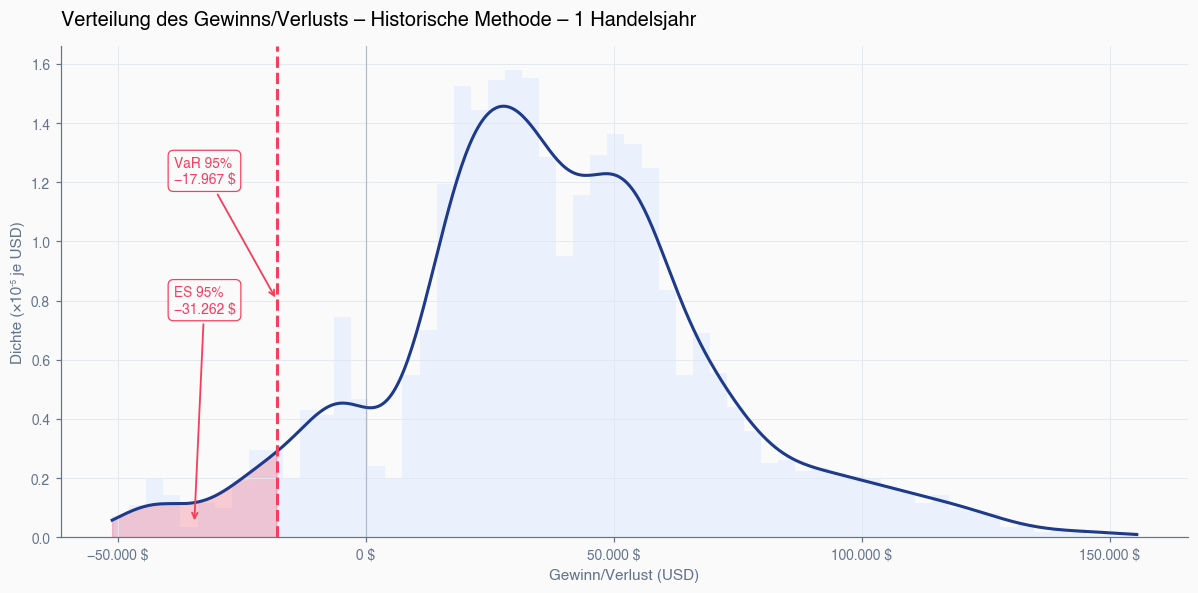

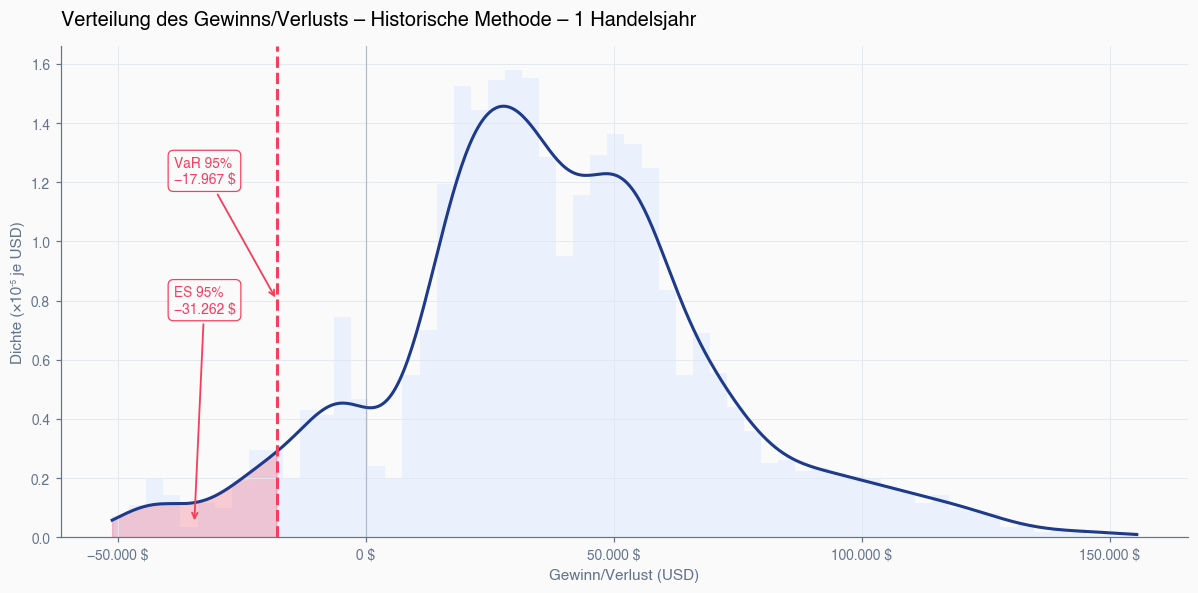

In [4]:
fig = plot_pnl_density_var_es(
    pf_log,
    capital=start_capital,
    confidence=0.95,
    horizon_days=days_1y,
    method="historical",
)
fig.savefig(f"{FIG_DIR}/prototype_1_pnl_density_var_es.png", bbox_inches="tight")
display(fig)


## Plot 2 — Drei Methoden im Vergleich

Historisch, Gauss-parametrisch, Lognormal-MC nebeneinander. Nur Linien, keine gefüllten Kurven — sonst wird das Brei. So sieht man auf einen Blick, dass die parametrische Normalverteilung den Tail unterschätzt.

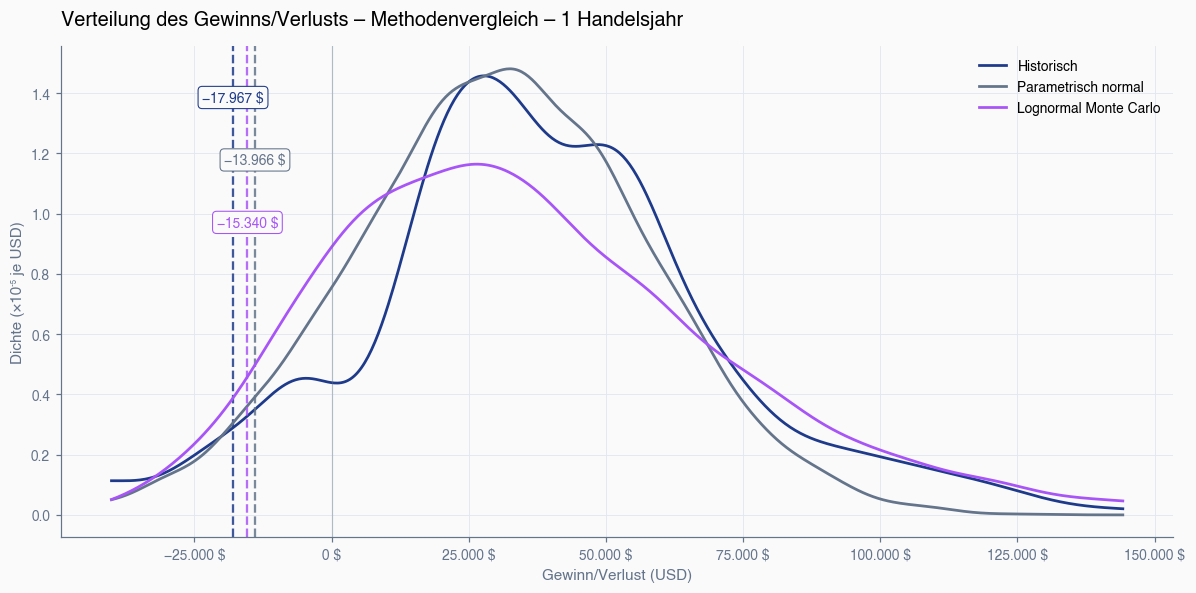

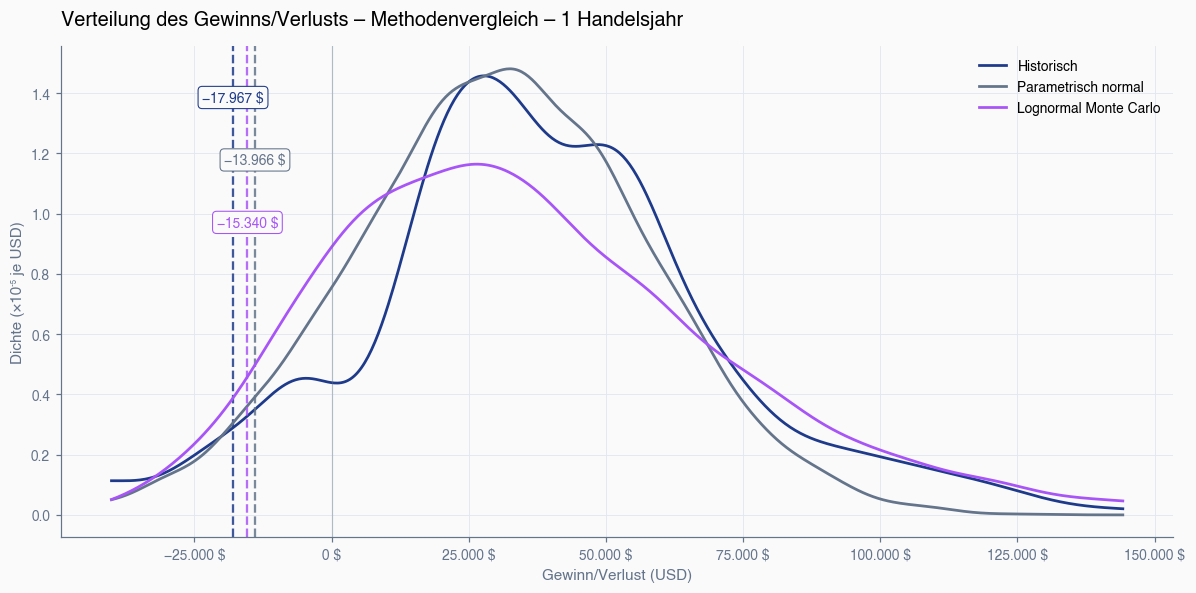

In [5]:
fig = plot_methods_overlay(
    pf_log,
    capital=start_capital,
    confidence=0.95,
    horizon_days=days_1y,
)
fig.savefig(f"{FIG_DIR}/prototype_2_methods_overlay.png", bbox_inches="tight")
display(fig)


## Plot 3 — Endwert-Fächer über 5 Jahre

Wo landet das Geld in 5 Jahren? Zwei Quantilbänder (5–95 außen, 25–75 innen) plus Median, alles in einer ruhigen Indigo-Skala. Die Endwerte stehen rechts am Plotrand mit Klartext-Labels — keine kryptischen "q05/q95" mehr.

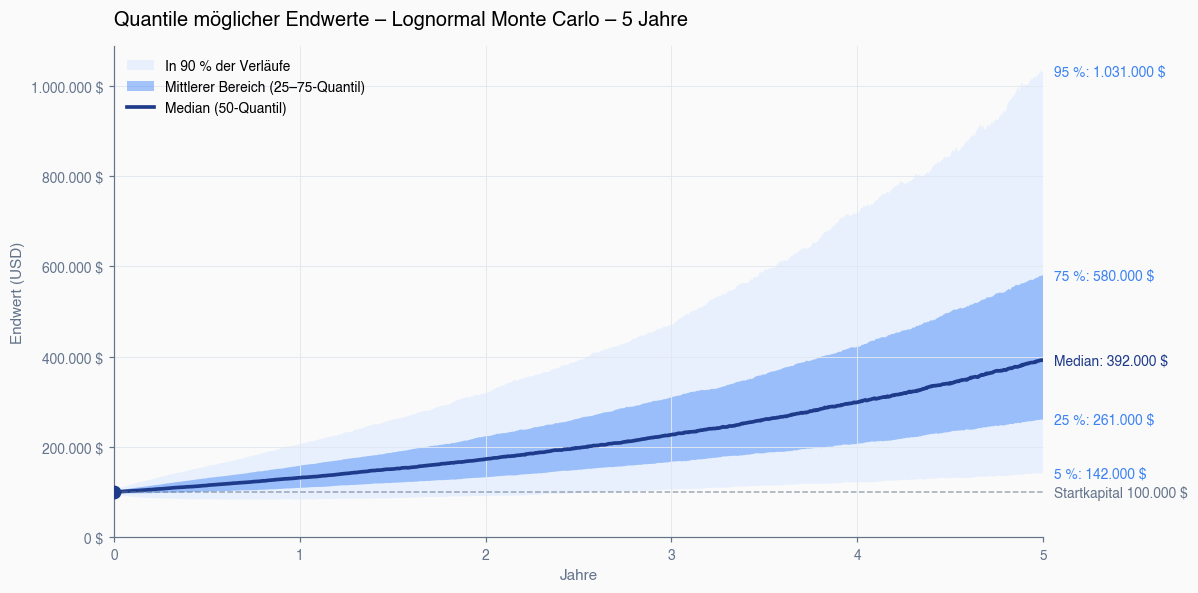

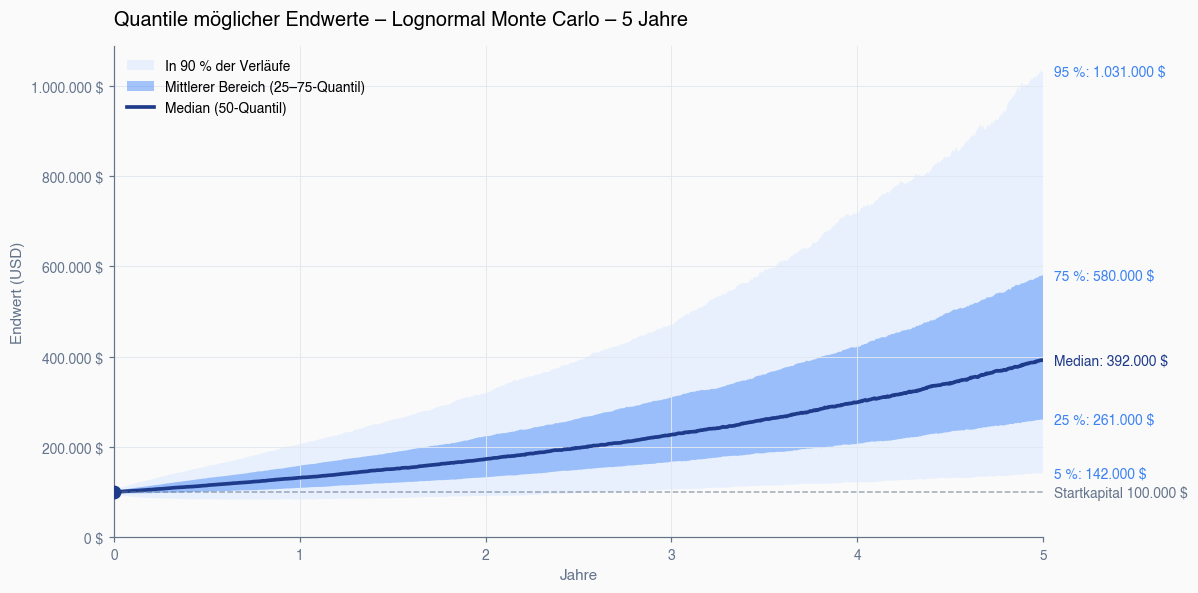

In [6]:
fig = plot_quantile_fan(
    pf_log,
    capital=start_capital,
    n_years=5,
)
fig.savefig(f"{FIG_DIR}/prototype_3_quantile_fan_5y.png", bbox_inches="tight")
display(fig)


## Plot 5 — Korrelations-Heatmap Mag7

Wir testen das mal als Heatmap, weil die sieben Tickers untereinander stark verbunden sein dürften und wir das im Tail-Risiko sowieso brauchen. Indigo für +1, Coral für −1, Off-White für 0 — passt zur Palette.

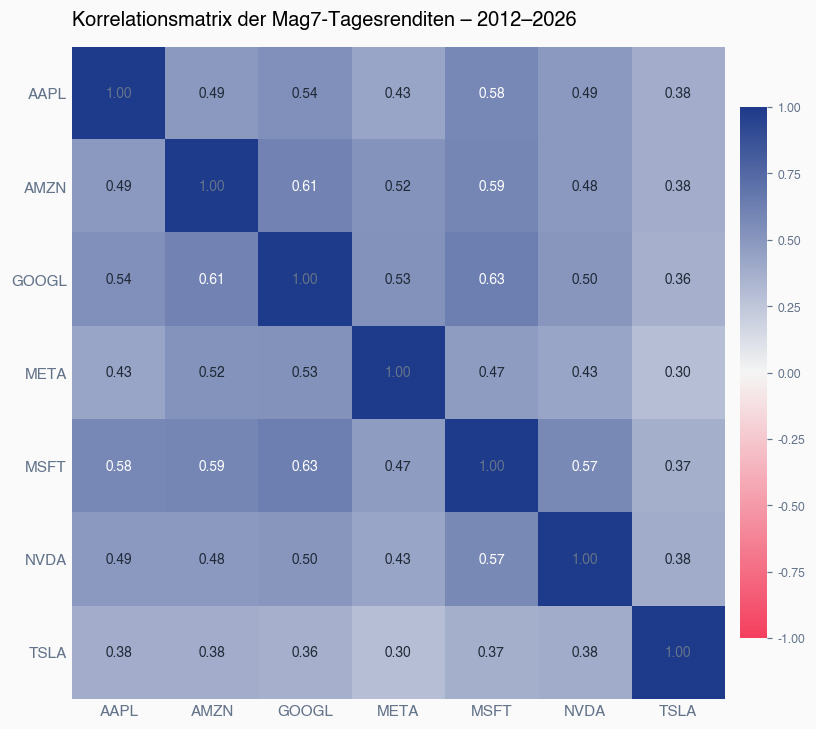

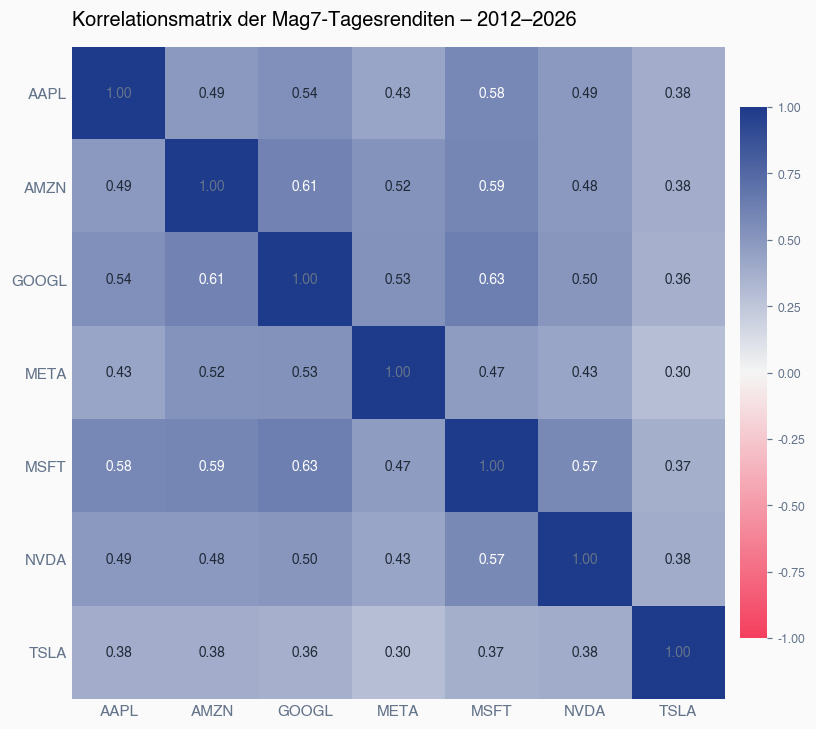

In [7]:
fig = plot_correlation_heatmap(returns_d, tickers=tickers)
fig.savefig(f"{FIG_DIR}/prototype_5_correlation_heatmap.png", bbox_inches="tight")
display(fig)


## Plot 6 — Bootstrap-Konfidenzintervalle um VaR

Wir testen das mal als Robustheits-Plot. Die Frage: wie unsicher ist die VaR-Zahl selbst, wenn man die Stichprobe leicht variiert? 500 Bootstrap-Resamples pro Methode, daraus 5/95-CI.

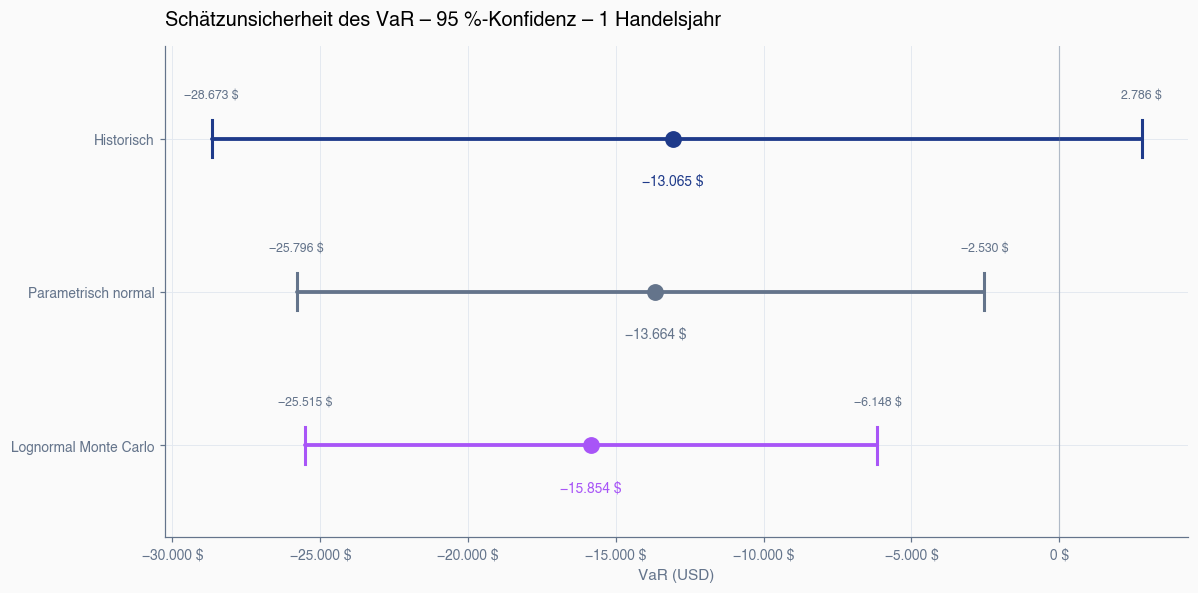

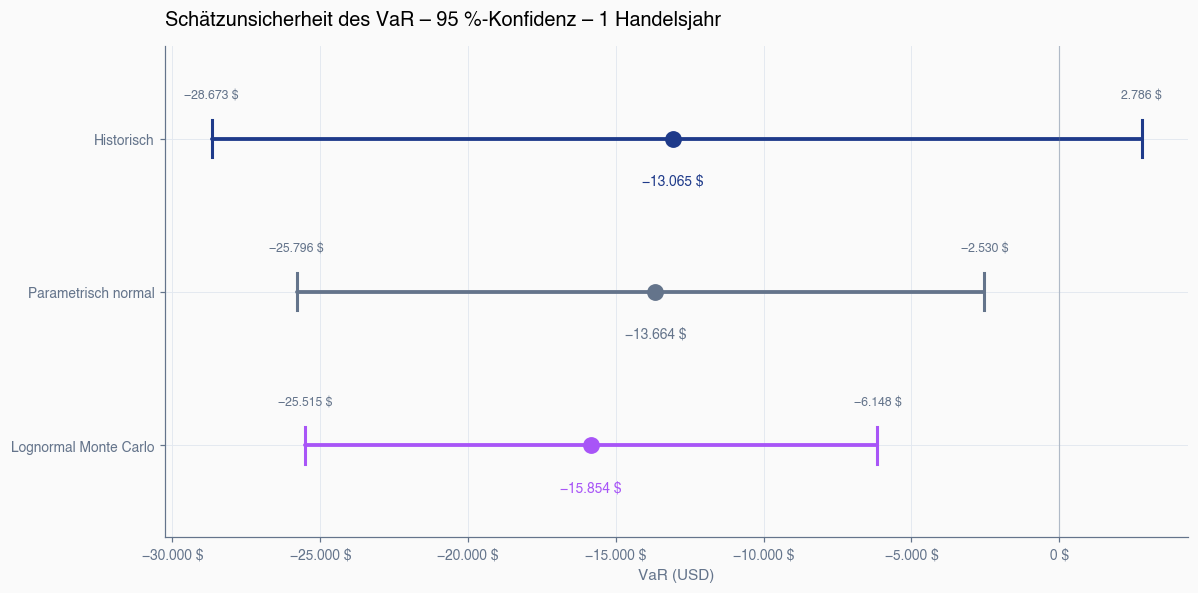

In [8]:
fig = plot_bootstrap_ci_var(
    pf_log,
    capital=start_capital,
    confidence=0.95,
    horizon_days=days_1y,
    n_bootstrap=500,
)
fig.savefig(f"{FIG_DIR}/prototype_6_bootstrap_ci.png", bbox_inches="tight")
display(fig)


## Plot 7 — Monte-Carlo-Pfad-Spaghetti

Vanguard-Style: 200 transparente Pfade als dünne Linien, darüber die Quantile als Linien (kein Fill, sonst geht der Spaghetti-Eindruck verloren). Höhere Figsize (12×6.5), damit der Plot nicht gequetscht aussieht.

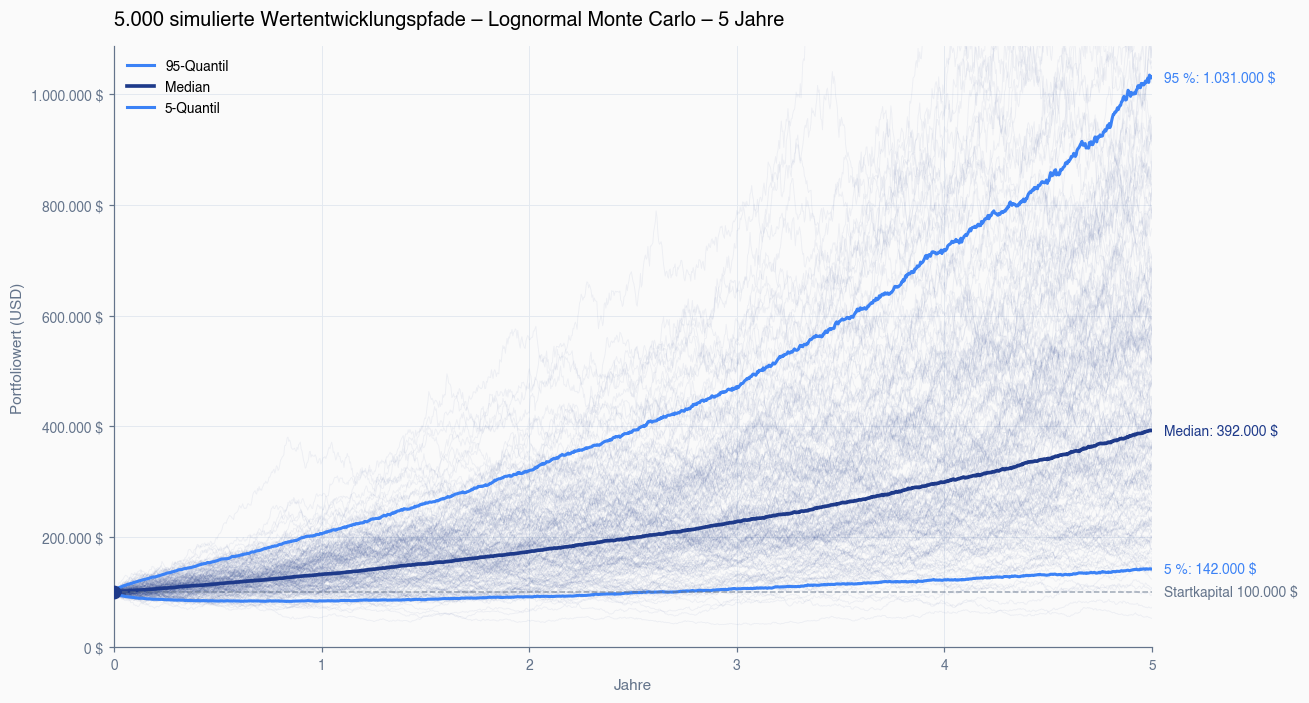

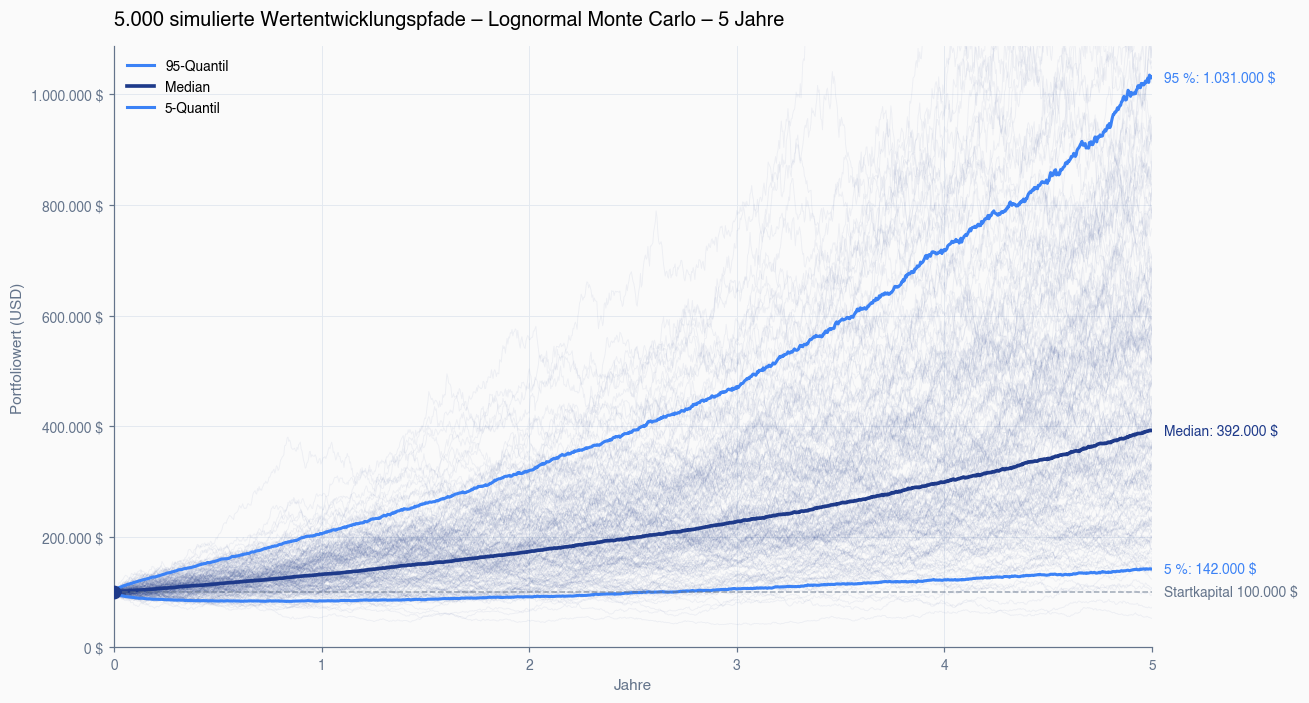

In [9]:
fig = plot_mc_spaghetti(
    pf_log,
    capital=start_capital,
    n_years=5,
    n_paths_total=5_000,
    n_paths_visible=200,
)
# `bbox_inches="tight"` verzerrt hier das 12×6.5-Aspect — daher pad_inches direkt setzen.
fig.savefig(f"{FIG_DIR}/prototype_7_mc_spaghetti.png", pad_inches=0.2)
display(fig)


## Plot 8 — Drawdown-Verteilung der MC-Pfade

Wir testen das mal, weil VaR/ES nur Endwerte anschauen — der schlimmste Punkt im Verlauf kann viel tiefer liegen. Pro Pfad maximaler Drawdown (relativ zum laufenden Hoch), dann Histogramm/KDE. `confidence` parametrisiert die Perzentil-Linie (Default 0.95 → 95-Perzentil).

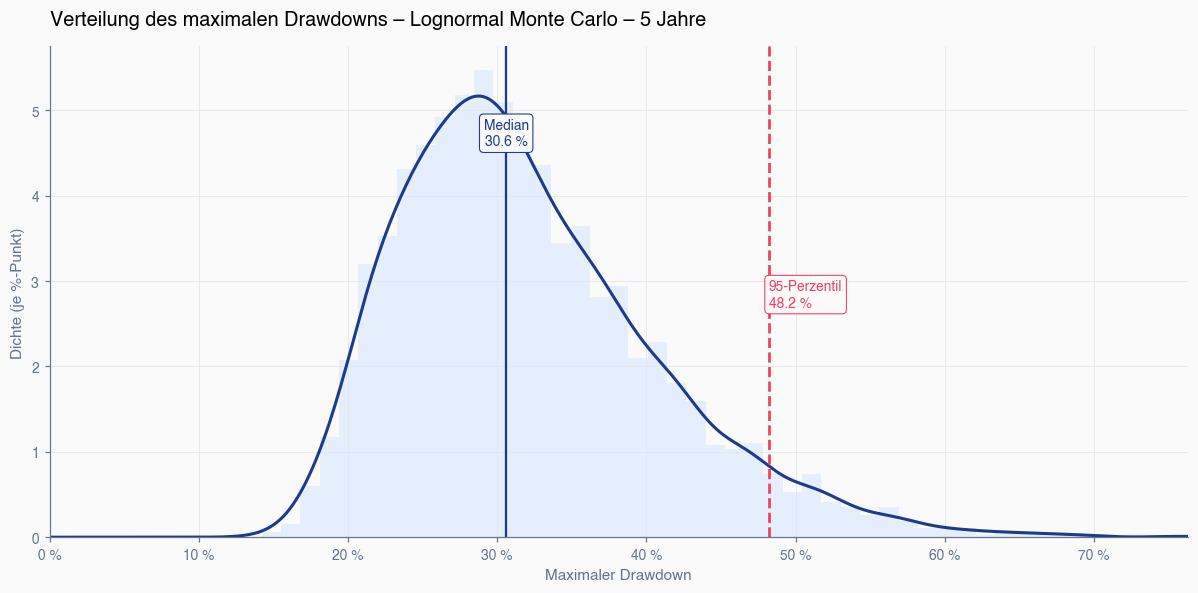

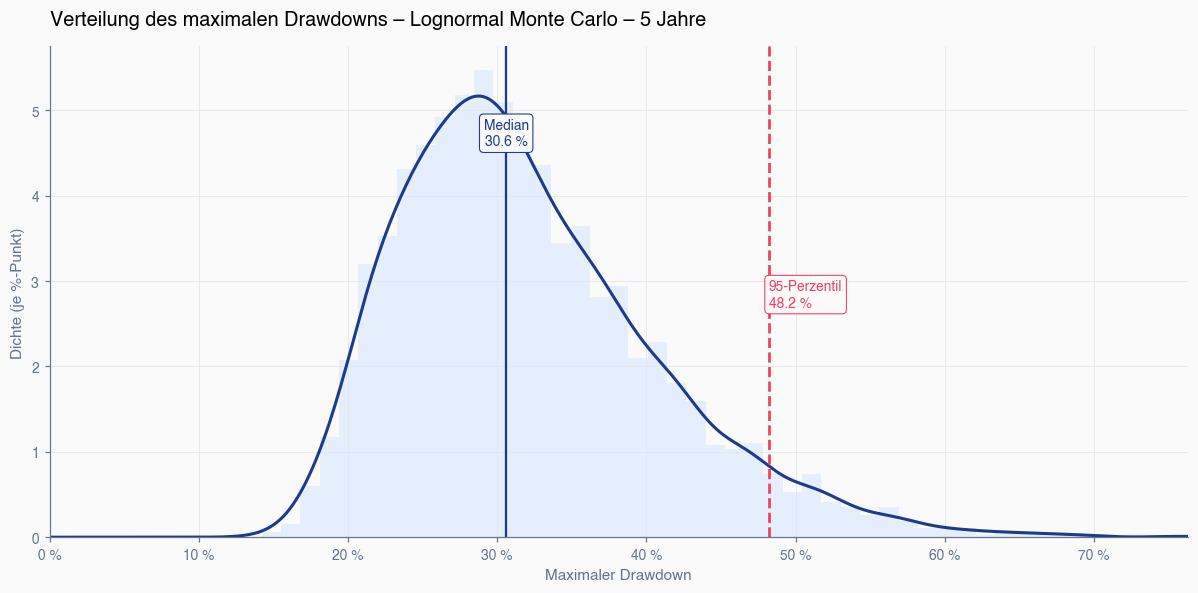

In [10]:
fig = plot_drawdown_distribution(
    pf_log,
    capital=start_capital,
    n_years=5,
    n_paths=5_000,
    confidence=0.95,
)
fig.savefig(f"{FIG_DIR}/prototype_8_drawdown_distribution.png", bbox_inches="tight")
display(fig)
